In [175]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import random

In [47]:
data=pd.read_csv('datasets/student_clustering.csv')
data
x=np.array(data)

In [184]:
def assign_clusters(centroids,x2):
    y_pred=[]
    for i in x2:
        mini=1000000000000
        idx=None
        for j in range(centroids.shape[0]):
            dist=np.dot(i.astype('float')-centroids[j],i.astype('float')-centroids[j].T)
            if mini>dist:
                mini=dist
                idx=j
        y_pred.append(idx)
    return y_pred

In [185]:
def move_centroids(X,y_pred):
    types=np.unique(y_pred)
    new_centroids=[]
    for i in types:
        new_centroids.append(X[y_pred==i].mean(axis=0))
    return np.array(new_centroids)

In [186]:
class kmeans:
    def __init__(self,n_clusters=2,max_iter=500):
        self.n_clusters=n_clusters
        self.max_iter=max_iter
        self.centroids=None
    def fit(self,x):
        np.random.seed(2300)
        self.centroids=np.array(x[[(np.random.sample(self.n_clusters)*x.shape[0]).astype('int')[0] for i in range(self.n_clusters)],:])
        for i in range(self.max_iter):
            y_pred=assign_clusters(self.centroids,x)
            old_centroids=self.centroids
            self.centroids=move_centroids(x,y_pred)
            if (old_centroids==self.centroids).all():
                return y_pred
                break
        

In [187]:
m1=kmeans()  # default n_clusters=2
y_pred=m1.fit(x)

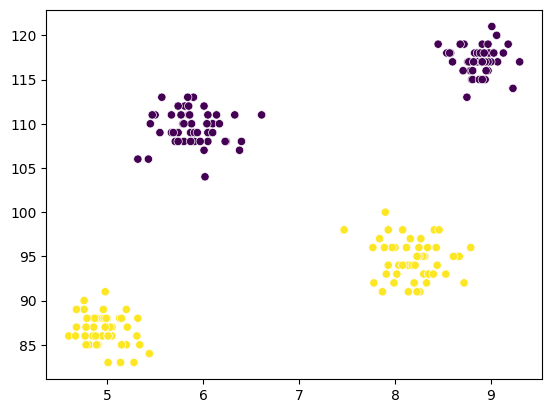

In [188]:
sns.scatterplot(x=x.T[0],y=x.T[1],c=y_pred)
plt.show()

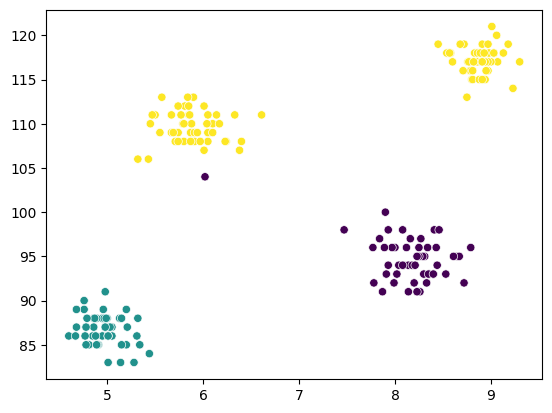

In [189]:
m2=kmeans(n_clusters=3)
sns.scatterplot(x=x.T[0],y=x.T[1],c=m2.fit(x))
plt.show()

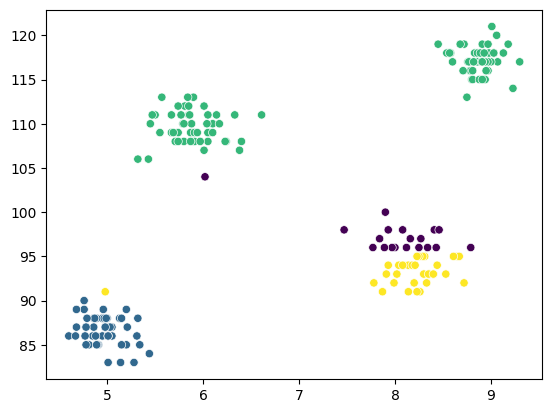

In [191]:
m3=kmeans(n_clusters=4)  # i am getting some error. dont know why
sns.scatterplot(x=x.T[0],y=x.T[1],c=m3.fit(x))
plt.show()